# 10 — Robustness (Week 5, step 2)

Subperiod stability (Newey–West), cost sensitivity (±50%), and threshold sensitivity for the
recommended strategy `v1_rmt+regime`. No Deflated Sharpe / PBO (dropped by decision — the
conclusions rest on tail-shape and out-of-sample nulls, not a single maximised Sharpe).

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
P = ROOT / "data" / "processed"; FIG = ROOT / "results" / "figures"; TAB = ROOT / "results" / "tables"
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.22, "axes.axisbelow": True, "figure.dpi": 150})
INK, MUTED = "#2b2b2b", "#767676"
COL = {"v0": "#767676", "v1rmt": "#4a3aa7", "regonly": "#1baf7a"}
ERAS = [("1996\u20132003", "1996", "2003"), ("2004\u20132007", "2004", "2007"),
        ("2008\u20132012", "2008", "2012"), ("2013\u20132019", "2013", "2019"),
        ("2020\u20132024", "2020", "2024")]

def nw_t(x, lags=63):
    x = pd.Series(x).dropna().astype(float)
    if len(x) < 5: return np.nan, np.nan
    res = sm.OLS(x.to_numpy(), np.ones((len(x), 1))).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return float(x.mean()), float(res.tvalues[0])

In [2]:
# A. The CRP premium by subperiod (window-matched, Newey-West) — the compression story
sig = pd.read_parquet(P / "signal.parquet"); sig["date"] = pd.to_datetime(sig["date"])
s = sig.set_index("date")["premium"]
rows = []
for lab, a, b in ERAS:
    mu, t = nw_t(s.loc[a:b])
    frac = (s.loc[a:b].dropna() > 0).mean()
    rows.append((lab, round(mu, 4), round(t, 2), f"{frac:.0%}"))
prem = pd.DataFrame(rows, columns=["period", "mean premium", "t-NW(63)", "% days > 0"]).set_index("period")
prem.to_csv(TAB / "table_premium_subperiods.csv")
print("Correlation risk premium by subperiod (implied - forward realised):"); prem

Correlation risk premium by subperiod (implied - forward realised):


,mean premium,t-NW(63),% days > 0
period,,,
1996–2003,0.0845,4.87,73%
2004–2007,0.0781,4.06,81%
2008–2012,0.1353,4.25,83%
2013–2019,0.0688,3.29,75%
2020–2024,0.0284,1.19,63%


In [3]:
# B. Strategy metrics by subperiod (net of costs) — is the edge stable across regimes?
STRATS = [("v0", "v0_net"), ("v1rmt", "v1rmt_net"), ("regonly", "regonly_net")]
def era_metrics(tag):
    d = pd.read_parquet(P / f"backtest_{tag}_daily.parquet"); d["date"] = pd.to_datetime(d["date"])
    q = pd.read_parquet(P / f"backtest_{tag}_quarterly.parquet"); q["rebalance_date"] = pd.to_datetime(q["rebalance_date"])
    out = {}
    for lab, a, b in ERAS:
        dr = d.set_index("date").loc[a:b, "ret"].astype(float)
        rq = q.set_index("rebalance_date").loc[a:b, "ret_q"].astype(float)
        cum = (1 + dr).cumprod()
        out[lab] = dict(sharpe=dr.mean()/dr.std()*np.sqrt(252) if dr.std() else np.nan,
                        skew=float(rq.skew()) if len(rq) > 2 else np.nan,
                        maxDD=float((cum/cum.cummax()-1).min()))
    return out
met = {name: era_metrics(tag) for name, tag in STRATS}
sharpe_tab = pd.DataFrame({name: {e: met[name][e]["sharpe"] for e, _, _ in ERAS} for name, _ in STRATS}).round(2)
sharpe_tab.to_csv(TAB / "table_strategy_subperiods_sharpe.csv")
print("Annualised Sharpe by subperiod (net):"); sharpe_tab

Annualised Sharpe by subperiod (net):


,v0,v1rmt,regonly
1996–2003,0.53,0.54,0.54
2004–2007,0.67,1.01,1.01
2008–2012,0.39,0.03,0.12
2013–2019,0.62,0.48,0.45
2020–2024,0.27,0.35,0.25


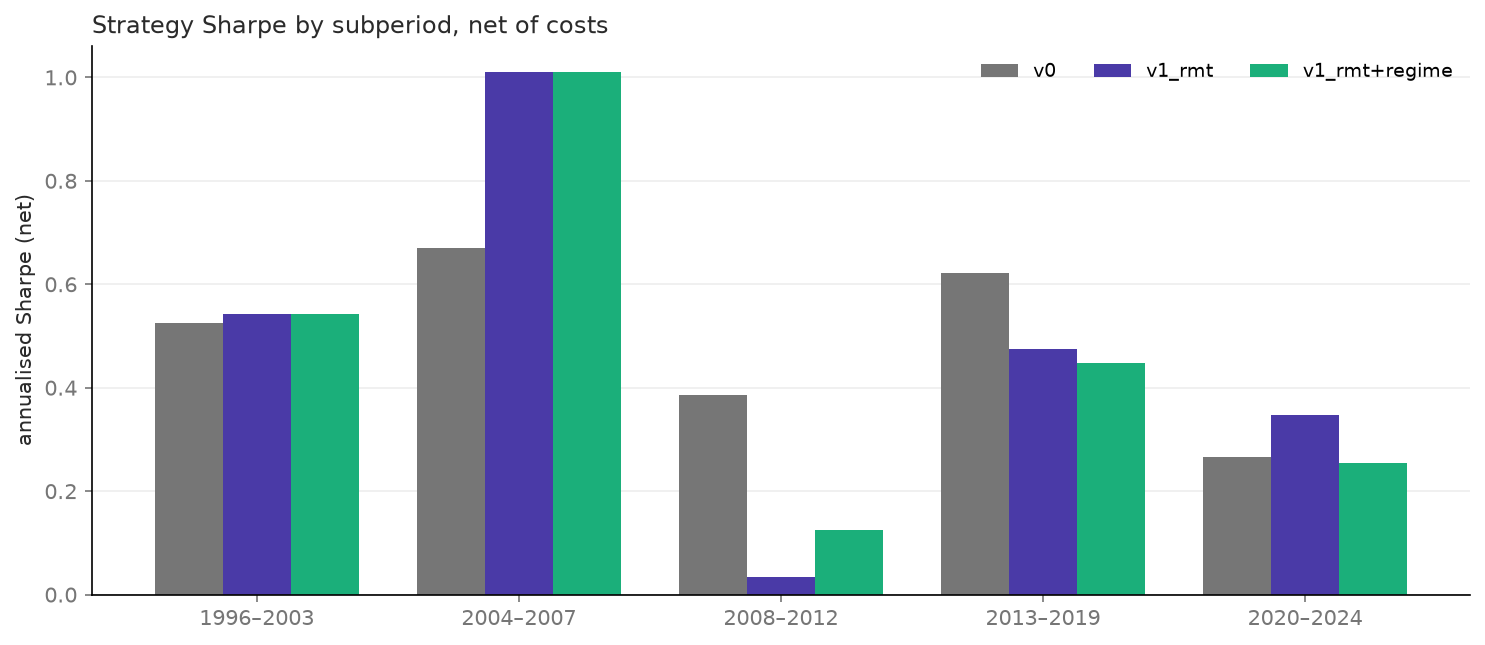

In [4]:
# FIG — subperiod Sharpe, grouped bars (one axis)
labels = [e for e, _, _ in ERAS]; x = np.arange(len(labels)); w = 0.26
fig, ax = plt.subplots(figsize=(10, 4.4))
for i, (name, _) in enumerate(STRATS):
    vals = [met[name][e]["sharpe"] for e, _, _ in ERAS]
    ax.bar(x + (i-1)*w, vals, w, color=COL[name], label={"v0":"v0","v1rmt":"v1_rmt","regonly":"v1_rmt+regime"}[name])
ax.axhline(0, color=MUTED, lw=0.7)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel("annualised Sharpe (net)", color=INK)
ax.set_title("Strategy Sharpe by subperiod, net of costs", loc="left", fontsize=11.5, color=INK)
ax.legend(frameon=False, fontsize=9, ncol=3, loc="upper right"); ax.tick_params(colors=MUTED); ax.grid(axis="x", alpha=0)
fig.tight_layout(); fig.savefig(FIG / "fig_subperiods.png", bbox_inches="tight"); plt.show()

In [5]:
# C. Cost & threshold sensitivity of v1_rmt+regime (loads robustness_sensitivity.json)
rob = json.load(open(P / "robustness_sensitivity.json"))
base = rob["base"]["stats"]
rows = [("BASE (gate 0.5, veto 0.67, cost x1.0)", base["sharpe"], base["skew"], base["maxDD"], base["trades"])]
for s in sorted(rob["cost_scale"], key=float):
    st = rob["cost_scale"][s]; rows.append((f"cost x{float(s):.1f}", st["sharpe"], st["skew"], st["maxDD"], st["trades"]))
for q in sorted(rob["veto_q"], key=float):
    st = rob["veto_q"][q]; rows.append((f"regime veto q={float(q):.2f}", st["sharpe"], st["skew"], st["maxDD"], st["trades"]))
for q in sorted(rob["gate_q"], key=float):
    st = rob["gate_q"][q]; rows.append((f"v1_rmt gate q={float(q):.2f}", st["sharpe"], st["skew"], st["maxDD"], st["trades"]))
sens = pd.DataFrame(rows, columns=["variant", "Sharpe", "skew", "maxDD", "trades"]).set_index("variant").round(3)
sens.to_csv(TAB / "table_sensitivity.csv")
print("Sensitivity of v1_rmt+regime (net):"); sens

Sensitivity of v1_rmt+regime (net):


,Sharpe,skew,maxDD,trades
variant,,,,
"BASE (gate 0.5, veto 0.67, cost x1.0)",0.571,0.998,-0.524,39
cost x0.5,0.670,1.270,-0.480,39
cost x1.5,0.461,0.661,-0.566,39
regime veto q=0.50,0.578,1.314,-0.524,33
regime veto q=0.80,0.568,0.883,-0.524,42
v1_rmt gate q=0.40,0.543,0.512,-0.534,50
v1_rmt gate q=0.60,0.562,1.300,-0.480,35


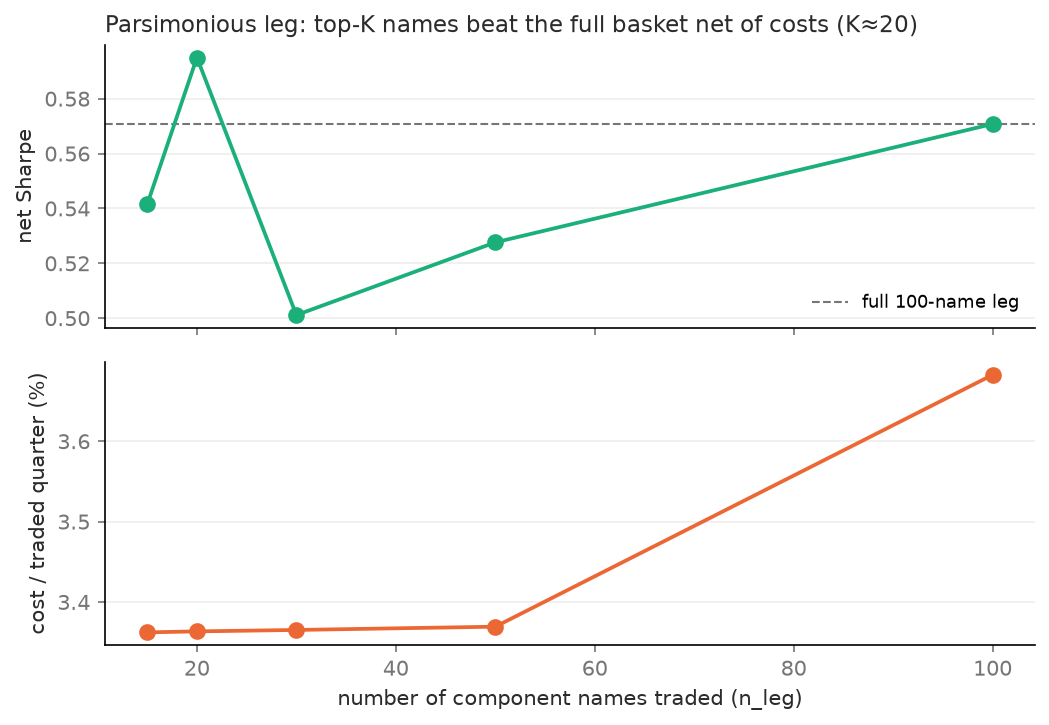

Parsimonious leg (net):


,Sharpe_net,skew_net,cost_per_quarter_%
n_leg,,,
15,0.541,0.954,3.362
20,0.595,1.141,3.363
30,0.501,0.662,3.365
50,0.528,0.852,3.369
100,0.571,0.998,3.683


In [6]:
# D. Parsimonious RMT leg — trade only the top-K names (fewer spreads paid).
# The RMT answer to frictions: does concentrating on big names cut cost enough to beat the full basket net?
par = json.load(open(P / "parsimonious_sweep.json"))
ks = ["15", "20", "30", "50", "full(100)"]; xk = [15, 20, 30, 50, 100]
sharpe_net = [par["net"][k]["sharpe"] for k in ks]
cost_q = [par["net"][k]["cost_q"] * 100 for k in ks]
ptab = pd.DataFrame({"n_leg": xk, "Sharpe_net": sharpe_net,
                     "skew_net": [par["net"][k]["skew"] for k in ks],
                     "cost_per_quarter_%": cost_q}).set_index("n_leg").round(3)
ptab.to_csv(TAB / "table_parsimonious.csv")

fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 5.2), sharex=True, gridspec_kw={"hspace": 0.12})
a1.axhline(par["net"]["full(100)"]["sharpe"], color=MUTED, ls="--", lw=1, label="full 100-name leg")
a1.plot(xk, sharpe_net, "-o", color="#1baf7a", lw=1.8, ms=7)
a1.set_ylabel("net Sharpe", color=INK); a1.legend(frameon=False, fontsize=8.5, loc="lower right")
a1.set_title("Parsimonious leg: top-K names beat the full basket net of costs (K≈20)",
             loc="left", fontsize=11, color=INK)
a2.plot(xk, cost_q, "-o", color="#eb6834", lw=1.8, ms=7)
a2.set_ylabel("cost / traded quarter (%)", color=INK); a2.set_xlabel("number of component names traded (n_leg)", color=INK)
for a in (a1, a2):
    a.tick_params(colors=MUTED); a.grid(axis="x", alpha=0)
fig.savefig(FIG / "fig_parsimonious.png", bbox_inches="tight"); plt.show()
print("Parsimonious leg (net):"); ptab

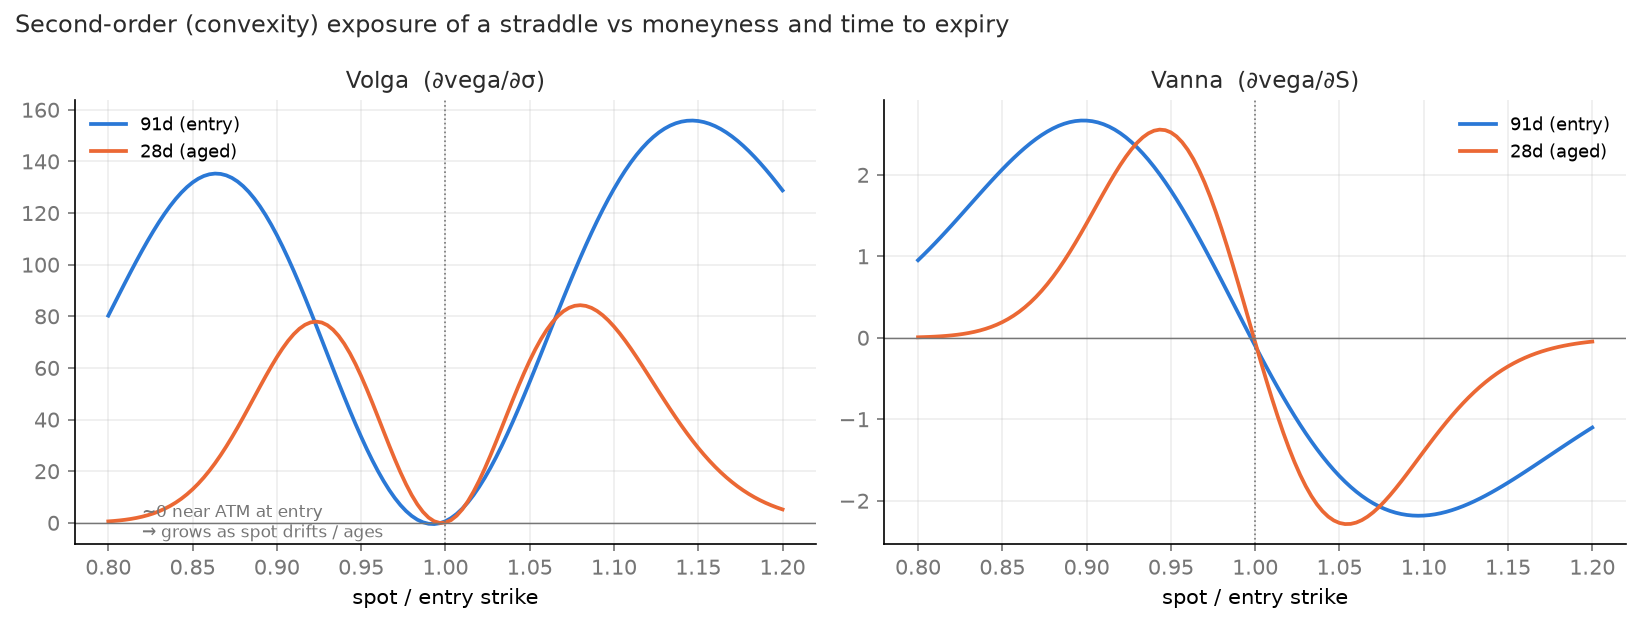

Q1-2018 book vega drift: entry -3116 → min -3116 (range 3628) — the frozen neutrality erodes in the spike.


In [7]:
# E. Vanna/Volga — convexity risk of the frozen book (qualitative, README §7).
# A straddle is near the 2nd-order-neutral point (d2=0) at entry; as it AGES and
# spot DRIFTS it leaves that point, so Volga (vega-of-vol) and Vanna (spot-vol
# cross-greek) grow — the vega-neutrality (a 1st-order property) then erodes.
from dispersion.utils.greeks import bs_greeks

sigma, r, q = 0.20, 0.03, 0.0
mny = np.linspace(0.80, 1.20, 121)          # spot / strike
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
for T, lab, c in [(91/365, "91d (entry)", "#2a78d6"), (28/365, "28d (aged)", "#eb6834")]:
    volga = [sum(bs_greeks(100*m, 100, sigma, T, r, q, cp)["volga"] for cp in "CP") for m in mny]
    vanna = [sum(bs_greeks(100*m, 100, sigma, T, r, q, cp)["vanna"] for cp in "CP") for m in mny]
    a1.plot(mny, volga, color=c, lw=1.8, label=lab)
    a2.plot(mny, vanna, color=c, lw=1.8, label=lab)
for a, ttl in [(a1, "Volga  (∂vega/∂σ)"), (a2, "Vanna  (∂vega/∂S)")]:
    a.axvline(1.0, color=MUTED, lw=0.8, ls=":"); a.axhline(0, color=MUTED, lw=0.7)
    a.set_xlabel("spot / entry strike"); a.set_title(ttl, fontsize=11, color=INK)
    a.legend(frameon=False, fontsize=8.5); a.tick_params(colors=MUTED)
a1.annotate("~0 near ATM at entry\n→ grows as spot drifts / ages", xy=(0.82, 0), xytext=(0.82, 0),
            fontsize=8, color=MUTED, va="center")
fig.suptitle("Second-order (convexity) exposure of a straddle vs moneyness and time to expiry",
             x=0.01, ha="left", fontsize=11.5, color=INK)
fig.tight_layout(); fig.savefig(FIG / "fig_vanna_volga.png", bbox_inches="tight"); plt.show()

# empirical tie-in: the realised vega drift of the book over Q1-2018 (Volmageddon)
led = pd.read_parquet(P / "backtest_v0_ledger.parquet"); led["date"] = pd.to_datetime(led["date"])
q18 = led[led["rebalance_date"] == "2017-12-29"].sort_values("date")
print(f"Q1-2018 book vega drift: entry {q18['vega'].iloc[0]:.0f} → min {q18['vega'].min():.0f} "
      f"(range {q18['vega'].max()-q18['vega'].min():.0f}) — the frozen neutrality erodes in the spike.")

## Reading (fill honestly after execution)

- Premium: strong 1996–2012, compressed post-2020 (limits-to-arbitrage). Stable sign?
- Strategy Sharpe by era: does v1_rmt+regime hold up in every subperiod, or is it driven by one era?
- Cost ±50%: how fragile is the net Sharpe? Does it survive at cost x1.5?
- Threshold sensitivity: is the tail improvement robust to the veto/gate quantiles, or knife-edge?